In [ ]:
data_folder="../Data/" #and libraries and funcitons
import sys
import numpy as np
import os
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from datetime import date
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.model_selection import StratifiedKFold, train_test_split
import tqdm
import re 
import time

sys.path.append(os.path.abspath("../Codes"))

sys.path.append(os.path.abspath("../_Deep_Learning"))

from Utils import split_create_windows, scale_newax
from Utils import freq_filter, windowize,  RegionWiseStandardizer

from BCI_Library import read_subject, saveresults_pickle, compute_welch
from BCI_Library import  train_single_model,select_regions_Cohen_effect_size, build_compiled_mlp

import tensorflow.keras as keras

def compute_power_spectra(data_2_MI, data_2_Rest, starttime=250, endtime=250):
    sfreq = 250
    miff = [8,12]
    maff = [12,30]

    WMI, WRe, FreqMI = compute_welch(data_2_MI, data_2_Rest, sfreq,
                                        kargs_welch={"fmin":miff[0], "fmax":maff[-1]},
                                        starttime=starttime, endtime=endtime,)

    return WMI, WRe


def selezione_cohen(WRe, WMI, train_idx, num_best_ROIs):
    training_index_Re = train_idx[np.where(train_idx<len(WRe))] 
    training_index_MI = train_idx[np.where(train_idx>=len(WRe))]-len(WRe)

    regions_selected, effect_size  = select_regions_Cohen_effect_size(wpsdMI=WMI[training_index_MI], 
                                                    wpsdRest=WRe[training_index_Re], 
                                                        important_regions=[], nbest_regions=num_best_ROIs)
    return regions_selected

2026-05-25 11:46:16.732330: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-25 11:46:16.808832: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-25 11:46:18.390880: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


## Massive training - all subjects

In [ ]:
Rows_all_subjects = pd.DataFrame({
    "ROIs": [],
    "NROIs":[],
    "DataType": [],
    "freqs_band": [],  
    "subject": [],
    "Classifier": [],
    "Accuracy": [],
    "Features": [],
    "Comments": [],
    "Region Selection": [],
    "Date": []
})

DataType = "EEG+MEG"
Region_Selection= "Cohen's d effect size selection starting from 3s" # "-"
num_best_ROIs = 8
region_specific = False

CNN_o_Autoencoder = "Autoencoder" # Autoencoder, # CNN, #SupervisedAutoencoder

saveresults = True
filepath_ori = "../Results/BCI_Performances/DNN/BCI_Performances_DNN_subject_"
all_subjects_name = "../Results/BCI_Performances/DNN/All_subjects_BCI_Performances_ultimate_DNN_region_selection_from_3s.pkl"

Features_name = CNN_o_Autoencoder + "_extracted"

# To be changed
# Tutti_soggetti = [0]
Addestramento = "Encoder_timeseries_Decoder_spectra_log_simpleNormalization_EEG_MEG"
pattern = re.compile(r"^\d{4}-\d{2}-\d{2}-\d{2}_\d{2}_\d{2}_" + re.escape(Addestramento) + r"$")

tempo_computazionale_iniziale = time.perf_counter()

for Tutti_soggetti in tqdm.tqdm([[i] for i in range(20)]):


    model_path_1 = f"../_Deep_Learning/Models_trained/Subject_"
    # model path 2 = f"{subject_index}/"
    # model path 2.5 = f"{DataType}/"
    model_path_3 = f"{CNN_o_Autoencoder}" + ("s/" if CNN_o_Autoencoder=="Autoencoder" else "/")

    mm = model_path_1 + f"{Tutti_soggetti[0]}/" + f"{DataType}/" + model_path_3
    matching_addestramenti = [f for f in os.listdir(mm) if pattern.match(f)]
    
    if len(matching_addestramenti) != 1:
        raise Exception(f"Ho trovato {len(matching_addestramenti)} addestramenti corrispondenti a {Addestramento} per il soggetto {donor_subject}.", 
                        "Controlla bene se è quello che vuoi o se c'è un errore nei nomi delle cartelle.")
    model_path_4 = matching_addestramenti[0] + "/"

    lib_path = model_path_1 + f"{Tutti_soggetti[0]}/" + f"{DataType}/" + model_path_3 + model_path_4
    sys.path.append(os.path.abspath(lib_path))
    try:
        del MultiTaskModel_PowerSpectra
        print("ho resettato MultiTaskModel")
    except:
        print("non ho resettato MultiTaskModel")

    try :
        from _Backup_Library import MultiTaskModel_PowerSpectra
    except:
        from Deep_Library_BCI import MultiTaskModel_PowerSpectra
        raise Exception("Non ho caricato dal backup, controlla bene se è quello che vuoi")

    use_GRU = True if "GRU" in model_path_4.replace("/","").split("_") else False

    if CNN_o_Autoencoder == "CNN":
        model = MultiTaskModel_PowerSpectra(input_shape=(256,2), output_shape=24, use_classifier=True, use_decoder=False, use_GRU=use_GRU, build_convolutional_decoder = True, EEG_concat_MEG = True)
    if CNN_o_Autoencoder == "Autoencoder":
        model = MultiTaskModel_PowerSpectra(input_shape=(256,2), output_shape=24, use_classifier=False, use_decoder=True, use_GRU=use_GRU, build_convolutional_decoder = True, EEG_concat_MEG = True)
    if CNN_o_Autoencoder == "SupervisedAutoencoder":
        try:
            model = MultiTaskModel_PowerSpectra(input_shape=(256,2), output_shape=24, use_classifier=True, use_decoder=True, use_GRU=use_GRU, build_convolutional_decoder = True, EEG_concat_MEG = True)
        except:
            model = MultiTaskModel_PowerSpectra(input_shape=(256,2), output_shape=24, use_classifier=True, use_decoder=True, build_convolutional_decoder = True, EEG_concat_MEG = True)



    model.build(input_shape=(256,2))




    today = date.today()
    sfreq = 250
    seed = 224
    PFR = True
    random_seed=224

    n_folds=5
    kf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=seed)
    today = date.today()
    sfreq = 250

    start = 3           # seconds where to start to extract windows
    sampling_hz = 250;  start = start*sampling_hz
    input_shape = 256   # length of each window
    shift = 85          # points to shift for next window in data
    num_windows = 7     # how many windows to extract from each trial

    end = start + (num_windows-1)*shift + input_shape  # seconds where to end to extract windows (1500 == 6 seconds)


    verbose = False

    Classifier_names, meths = ["SVC"],[SVC]  #["LDA", "SVC", "RandomForest"],[LDA, SVC, RandomForestClassifier] # ["MLP"], ["MLP"]
    MLP_fit_kwargs={'epochs':20, 'batch_size':32}
    DataTypes = [DataType]
    rl = None
    for DataType in DataTypes:
        for Classifier_name, meth in zip(Classifier_names,meths):
            
            Rows = pd.DataFrame({
                "ROIs": [],
                "NROIs":[],
                "DataType": [],
                "freqs_band": [],  
                "subject": [],
                "Classifier": [],
                "Accuracy": [],
                "Features": [],
                "Comments": [],
                "Region Selection": [],
                "Date": []
            })
            if rl is None: rl = Rows
        
            print("\n\n"+"#"*30+"\n",DataType,Classifier_name)
            for subject_index in Tutti_soggetti:

                model_path = model_path_1 + f"{subject_index}/" + f"{DataType}/" + model_path_3 + model_path_4
                Comments = model_path_4[:-1]+ f" Subject addestramento {subject_index}"

                filepath = filepath_ori + f"{subject_index}.pkl"
                file_input = filepath
                file_output = filepath

                data_2_Rest_EEG = read_subject(data_folder, "EEG", "Baseline",subject_index,verbose=verbose)
                data_2_MI_EEG = read_subject(data_folder, "EEG", "MI",subject_index,verbose=verbose)
                data_EEG = np.concatenate((data_2_Rest_EEG, data_2_MI_EEG), axis=0)
                WMI_EEG, WRe_EEG = compute_power_spectra(data_2_MI_EEG,data_2_Rest_EEG, starttime=750)
                data_EEG = freq_filter(data_EEG, sf=250, freqs=[4,45], type_filter="bandpass") # axis = -1 by default
                data_EEG = data_EEG[:,:,start:end]        #  data.shape = (192, rois_selected, 748)


                data_2_Rest_MEG = read_subject(data_folder, "MEG", "Baseline",subject_index,verbose=verbose)
                data_2_MI_MEG = read_subject(data_folder, "MEG", "MI",subject_index,verbose=verbose)
                data_MEG = np.concatenate((data_2_Rest_MEG, data_2_MI_MEG), axis=0)
                WMI_MEG, WRe_MEG = compute_power_spectra(data_2_MI_MEG,data_2_Rest_MEG, starttime=750)
                data_MEG = freq_filter(data_MEG, sf=250, freqs=[4,45], type_filter="bandpass") # axis = -1 by default
                data_MEG = data_MEG[:,:,start:end]        #  data.shape = (192, rois_selected, 748)



                # y shape: (n_trials,) with negative values for Rest and positive for MI
                y_EEG = np.concatenate([-np.ones((data_2_Rest_EEG.shape[0])), np.ones((data_2_MI_EEG.shape[0]))])
                y_MEG = np.concatenate([-np.ones((data_2_Rest_MEG.shape[0])), np.ones((data_2_MI_MEG.shape[0]))])

                assert np.array_equal(y_EEG, y_MEG), "Le etichette di EEG e MEG non corrispondono. Controlla i dati."
                
                fold_accuracies = []
                tutti_fold_selezioni_regioni = []
                for fold_idx, (train_idx, block_idx) in enumerate(kf.split(data_EEG, y_EEG)):
                ########################## DATA PREPROCESSING ##########################################
                # TODO create (num_windows,0)
                    Feat_train_regions_selected = None  #np.empty((len(train_idx)*11,0))
                    Feat_test_regions_selected = None # np.empty()
                    
                    # Scelta di regioni: scelgo tutte le regioni tra EEG e MEG
                    regions_selected_EEG = selezione_cohen(WRe_EEG, WMI_EEG, train_idx, num_best_ROIs)
                    regions_selected_MEG = selezione_cohen(WRe_MEG, WMI_MEG, train_idx, num_best_ROIs)
                    regions_selected = list(set(regions_selected_EEG) | set(regions_selected_MEG))
                    


                    regions_selected.sort()
                    print("\n Per il fold ", fold_idx, " Ho selezionato un numero di regioni pari a ", len(regions_selected), regions_selected)
                    tutti_fold_selezioni_regioni.append(regions_selected)
                    
                    for region_index, regione in enumerate(regions_selected):
                    
                        split_num = fold_idx+1
                        if region_specific:
                            model.load_weights(model_path+f"Split_{split_num}/Region_{regione}/model.weights.h5")
                        else:
                            model.load_weights(model_path+f"Split_{split_num}/model.weights.h5")

                        x_train_MEG, y_train_MEG, x_val_MEG, y_val_MEG, x_test_MEG, y_test_MEG = (
                        split_create_windows(data_MEG, y_MEG, train_idx, block_idx, 1, win_len=input_shape, shift=shift,
                            random_seed=random_seed, regione=regione)
                            )

                        x_train_MEG, x_val_MEG, x_test_MEG = scale_newax (x_train_MEG, y_train_MEG, x_val_MEG, y_val_MEG, x_test_MEG, y_test_MEG, scaler=RegionWiseStandardizer())

                        x_train_EEG, y_train_EEG, x_val_EEG, y_val_EEG, x_test_EEG, y_test_EEG = (
                        split_create_windows(data_EEG, y_EEG, train_idx, block_idx, 1, win_len=input_shape, shift=shift,
                            random_seed=random_seed, regione=regione)
                            )
                    
                        x_train_EEG, x_val_EEG, x_test_EEG = scale_newax (x_train_EEG, y_train_EEG, x_val_EEG, y_val_EEG, x_test_EEG, y_test_EEG, scaler=RegionWiseStandardizer())

                    
                        # TODO unito EEG e MEG per train, val e test
                        x_train = np.concatenate((x_train_EEG, x_train_MEG), axis=-1)  # shape (n_windows, timepoints, 2)
                        x_test = np.concatenate((x_test_EEG, x_test_MEG), axis=-1)  # shape (n_windows, timepoints, 2)


                        Features_training_1_regione = model.encoder(x_train)
                        Features_test_1_regione = model.encoder(x_test)
                        # Features_training_1_regione  shape (n_windows,16)
                        
                        
                        ################################### Feature Extractions ##########################################
                        if Feat_train_regions_selected is None:
                            Feat_train_regions_selected = np.empty((Features_training_1_regione.shape[0],0))
                            Feat_test_regions_selected = np.empty((Features_test_1_regione.shape[0],0))

                        Feat_train_regions_selected = np.concatenate((Feat_train_regions_selected,tf.reshape(Features_training_1_regione, (Features_training_1_regione.shape[0], -1))),axis = 1) # asse di regione
                        Feat_test_regions_selected = np.concatenate((Feat_test_regions_selected,tf.reshape(Features_test_1_regione, (Features_test_1_regione.shape[0], -1))),axis = 1) # asse di regione


                    Feat_All_regions_selected = np.concatenate((Feat_train_regions_selected,Feat_test_regions_selected))
                    # Feat_.shape (Trials, selected_ROIs, features for Roi)
                    labels_All = np.concatenate(((y_train_EEG > 0).astype(int),(y_test_EEG > 0).astype(int)))

                    train_idx_model = [_ for _ in range(len(Feat_train_regions_selected))]
                    val_idx_model = [_ + len(Feat_train_regions_selected) for _ in range(len(Feat_test_regions_selected))]


                    if Classifier_name.lower()=="mlp":
                            meth = build_compiled_mlp(input_dim=Feat_All_regions_selected.shape[1])
                            
                    acc, cm, model_classifier = train_single_model(Feat_All_regions_selected, labels_All,
                                                        train_idx_model, val_idx_model, method=meth, seed=224, fit_kwargs=MLP_fit_kwargs)

                    fold_accuracies.append(acc)
                    if verbose:
                        print(f"Fold {fold_idx+1} accuracy: {acc:.4f}, Confusion matrix:")
                        print(cm)

                    #####################################################################################################################

                if verbose:
                    print("\n==================================\n","Mean accuracy:", np.mean(fold_accuracies))
                    print("Std accuracy:", np.std(fold_accuracies))

                new_row = {
                    "ROIs": [regions_selected],
                    "NROIs":[len(regions_selected)],
                    "DataType": [DataType],
                    "freqs_band": ["-"],  
                    "subject": [subject_index],
                    "Classifier": [Classifier_name], #SVC, #RandomForest, #LDA
                    "Accuracy": [fold_accuracies],
                    "Features": [Features_name],
                    "Comments": [Comments],
                    "Region Selection": [Region_Selection],
                    "Date": [today],
                    "Personalized_Freq_Range": ["-"],
                }
                Rows=pd.concat((Rows,pd.DataFrame(new_row)))
                rl = pd.concat((rl,Rows))
                Rows_all_subjects = pd.concat((Rows_all_subjects, pd.DataFrame(new_row)))
            

            if saveresults:
                saveresults_pickle(Rows, inputfile=file_input, outputfile=file_output, backup=True)

if saveresults:
    Rows_all_subjects.to_pickle(all_subjects_name)
    print("\n\nHo salvato i risultati di tutti i soggetti in ", all_subjects_name)
print("\n\n\nTEMPOO totale", time.perf_counter()-tempo_computazionale_iniziale, "\n\n\n")

  0%|          | 0/20 [00:00<?, ?it/s]

non ho resettato MultiTaskModel


I0000 00:00:1779702439.004266   55304 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 6821 MB memory:  -> device: 0, name: Quadro RTX 4000, pci bus id: 0000:5b:00.0, compute capability: 7.5
I0000 00:00:1779702439.005059   55304 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 6761 MB memory:  -> device: 1, name: Quadro RTX 4000, pci bus id: 0000:9e:00.0, compute capability: 7.5




##############################
 EEG+MEG SVC

 Per il fold  0  Ho selezionato un numero di regioni pari a  13 [6, 15, 23, 27, 32, 33, 43, 45, 46, 48, 49, 51, 59]


2026-05-25 11:47:30.391010: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91800


...

There are 0 duplicated items (based on all columns except Date, ROIs, Accuracy).
 Index of the duplicated items: []

Results saved at: ../Results/BCI_Performances/DNN/BCI_Performances_DNN_subject_17.pkl
ho resettato MultiTaskModel


##############################
 EEG+MEG SVC

 Per il fold  0  Ho selezionato un numero di regioni pari a  15 [2, 9, 18, 19, 25, 31, 33, 39, 44, 45, 47, 48, 49, 60, 61]

 Per il fold  1  Ho selezionato un numero di regioni pari a  16 [2, 3, 5, 9, 18, 25, 33, 39, 44, 45, 47, 48, 49, 60, 61, 67]

 Per il fold  2  Ho selezionato un numero di regioni pari a  14 [2, 3, 8, 18, 24, 33, 39, 44, 45, 48, 49, 52, 60, 61]

 Per il fold  3  Ho selezionato un numero di regioni pari a  16 [2, 3, 14, 18, 19, 33, 36, 38, 44, 45, 47, 48, 49, 60, 61, 64]

 Per il fold  4  Ho selezionato un numero di regioni pari a  15 [2, 3, 8, 18, 25, 33, 36, 39, 42, 44, 48, 60, 61, 65, 67]


 95%|█████████▌| 19/20 [06:56<00:22, 22.84s/it]

There are 0 duplicated items (based on all columns except Date, ROIs, Accuracy).
 Index of the duplicated items: []

Results saved at: ../Results/BCI_Performances/DNN/BCI_Performances_DNN_subject_18.pkl
ho resettato MultiTaskModel


##############################
 EEG+MEG SVC

 Per il fold  0  Ho selezionato un numero di regioni pari a  13 [4, 32, 33, 44, 45, 46, 47, 48, 49, 59, 62, 63, 66]

 Per il fold  1  Ho selezionato un numero di regioni pari a  13 [4, 32, 33, 44, 45, 46, 47, 48, 50, 51, 59, 62, 63]

 Per il fold  2  Ho selezionato un numero di regioni pari a  12 [4, 32, 33, 44, 45, 46, 47, 48, 51, 59, 62, 63]

 Per il fold  3  Ho selezionato un numero di regioni pari a  13 [4, 32, 33, 44, 45, 46, 47, 48, 49, 51, 59, 62, 63]

 Per il fold  4  Ho selezionato un numero di regioni pari a  13 [4, 32, 33, 44, 45, 46, 47, 48, 51, 59, 62, 63, 66]


100%|██████████| 20/20 [07:18<00:00, 21.93s/it]

There are 0 duplicated items (based on all columns except Date, ROIs, Accuracy).
 Index of the duplicated items: []

Results saved at: ../Results/BCI_Performances/DNN/BCI_Performances_DNN_subject_19.pkl


## Massive training all subjects - classification with the whole 5 (3)s window

concatenate features extracted from 1 sec windows

In [ ]:
Rows_all_subjects = pd.DataFrame({
    "ROIs": [],
    "NROIs":[],
    "DataType": [],
    "freqs_band": [],  
    "subject": [],
    "Classifier": [],
    "Accuracy": [],
    "Features": [],
    "Comments": [],
    "Region Selection": [],
    "Date": []
})

# To be changed
# Tutti_soggetti = [0]
Addestramento = "Encoder_timeseries_Decoder_spectra_log_simpleNormalization_EEG_MEG"
pattern = re.compile(r"^\d{4}-\d{2}-\d{2}-\d{2}_\d{2}_\d{2}_" + re.escape(Addestramento) + r"$")
saveresults = False
filepath_ori = "../Results/BCI_Performances/DNN/BCI_Performances_DNN_subject_"

for Tutti_soggetti in tqdm.tqdm([[i] for i in range(20)]):

    DataType = "EEG+MEG"
    CNN_o_Autoencoder = "Autoencoder" # Autoencoder, # CNN, #SupervisedAutoencoder

    region_specific = False

    model_path_1 = f"../_Deep_Learning/Models_trained/Subject_"
    # model path 2 = f"{subject_index}/"
    # model path 2.5 = f"{DataType}/"
    model_path_3 = f"{CNN_o_Autoencoder}" + ("s/" if CNN_o_Autoencoder=="Autoencoder" else "/")

    mm = model_path_1 + f"{Tutti_soggetti[0]}/" + f"{DataType}/" + model_path_3
    matching_addestramenti = [f for f in os.listdir(mm) if pattern.match(f)]
    
    if len(matching_addestramenti) != 1:
        raise Exception(f"Ho trovato {len(matching_addestramenti)} addestramenti corrispondenti a {Addestramento} per il soggetto {donor_subject}.", 
                        "Controlla bene se è quello che vuoi o se c'è un errore nei nomi delle cartelle.")
    model_path_4 = matching_addestramenti[0] + "/"

    lib_path = model_path_1 + f"{Tutti_soggetti[0]}/" + f"{DataType}/" + model_path_3 + model_path_4
    sys.path.append(os.path.abspath(lib_path))
    try:
        del MultiTaskModel_PowerSpectra
        print("ho resettato MultiTaskModel")
    except:
        print("non ho resettato MultiTaskModel")

    try :
        from _Backup_Library import MultiTaskModel_PowerSpectra
    except:
        from Deep_Library_BCI import MultiTaskModel_PowerSpectra
        raise Exception("Non ho caricato dal backup, controlla bene se è quello che vuoi")

    use_GRU = True if "GRU" in model_path_4.replace("/","").split("_") else False

    if CNN_o_Autoencoder == "CNN":
        model = MultiTaskModel_PowerSpectra(input_shape=(256,2), output_shape=24, use_classifier=True, use_decoder=False, use_GRU=use_GRU, build_convolutional_decoder = True, EEG_concat_MEG = True)
    if CNN_o_Autoencoder == "Autoencoder":
        model = MultiTaskModel_PowerSpectra(input_shape=(256,2), output_shape=24, use_classifier=False, use_decoder=True, use_GRU=use_GRU, build_convolutional_decoder = True, EEG_concat_MEG = True)
    if CNN_o_Autoencoder == "SupervisedAutoencoder":
        try:
            model = MultiTaskModel_PowerSpectra(input_shape=(256,2), output_shape=24, use_classifier=True, use_decoder=True, use_GRU=use_GRU, build_convolutional_decoder = True, EEG_concat_MEG = True)
        except:
            model = MultiTaskModel_PowerSpectra(input_shape=(256,2), output_shape=24, use_classifier=True, use_decoder=True, build_convolutional_decoder = True, EEG_concat_MEG = True)



    model.build(input_shape=(256,2))



    today = date.today()
    sfreq = 250

    seed = 224

    Features_name = CNN_o_Autoencoder + "_extracted"
    Region_Selection= "Cohen's d effect size selection" # "-"

    PFR = True

    random_seed=224

    n_folds=5
    kf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=seed)
    today = date.today()
    sfreq = 250

    start = 1           # seconds where to start to extract windows
    sampling_hz = 250;  start = start*sampling_hz
    input_shape = 256   # length of each window
    shift = 250          # points to shift for next window in data
    num_windows = 5     # how many windows to extract from each trial

    end = start + (num_windows-1)*shift + input_shape  # seconds where to end to extract windows (1500 == 6 seconds)

    num_best_ROIs = 8


    verbose = False

    Classifier_names, meths = ["SVC"],[SVC]  #["LDA", "SVC", "RandomForest"],[LDA, SVC, RandomForestClassifier] # ["MLP"], ["MLP"]
    MLP_fit_kwargs={'epochs':20, 'batch_size':32}
    DataTypes = [DataType]
    rl = None
    for DataType in DataTypes:
        for Classifier_name, meth in zip(Classifier_names,meths):
            
            Rows = pd.DataFrame({
                "ROIs": [],
                "NROIs":[],
                "DataType": [],
                "freqs_band": [],  
                "subject": [],
                "Classifier": [],
                "Accuracy": [],
                "Features": [],
                "Comments": [],
                "Region Selection": [],
                "Date": []
            })
            if rl is None: rl = Rows
        
            print("\n\n"+"#"*30+"\n",DataType,Classifier_name)
            for subject_index in Tutti_soggetti:

                model_path = model_path_1 + f"{subject_index}/" + f"{DataType}/" + model_path_3 + model_path_4
                Comments = model_path_4[:-1]+ f" Subject addestramento {subject_index}"

                filepath = filepath_ori + f"{subject_index}.pkl"
                file_input = filepath
                file_output = filepath

                data_2_Rest_EEG = read_subject(data_folder, "EEG", "Baseline",subject_index,verbose=verbose)
                data_2_MI_EEG = read_subject(data_folder, "EEG", "MI",subject_index,verbose=verbose)
                data_EEG = np.concatenate((data_2_Rest_EEG, data_2_MI_EEG), axis=0)
                WMI_EEG, WRe_EEG = compute_power_spectra(data_2_MI_EEG,data_2_Rest_EEG)
                data_EEG = freq_filter(data_EEG, sf=250, freqs=[4,45], type_filter="bandpass") # axis = -1 by default
                data_EEG = data_EEG[:,:,start:end]        #  data.shape = (192, rois_selected, 748)


                data_2_Rest_MEG = read_subject(data_folder, "MEG", "Baseline",subject_index,verbose=verbose)
                data_2_MI_MEG = read_subject(data_folder, "MEG", "MI",subject_index,verbose=verbose)
                data_MEG = np.concatenate((data_2_Rest_MEG, data_2_MI_MEG), axis=0)
                WMI_MEG, WRe_MEG = compute_power_spectra(data_2_MI_MEG,data_2_Rest_MEG)
                data_MEG = freq_filter(data_MEG, sf=250, freqs=[4,45], type_filter="bandpass") # axis = -1 by default
                data_MEG = data_MEG[:,:,start:end]        #  data.shape = (192, rois_selected, 748)



                # y shape: (n_trials,) with negative values for Rest and positive for MI
                y_EEG = np.concatenate([-np.ones((data_2_Rest_EEG.shape[0])), np.ones((data_2_MI_EEG.shape[0]))])
                y_MEG = np.concatenate([-np.ones((data_2_Rest_MEG.shape[0])), np.ones((data_2_MI_MEG.shape[0]))])

                assert np.array_equal(y_EEG, y_MEG), "Le etichette di EEG e MEG non corrispondono. Controlla i dati."
                
                fold_accuracies = []
                tutti_fold_selezioni_regioni = []
                for fold_idx, (train_idx, block_idx) in enumerate(kf.split(data_EEG, y_EEG)):
                ########################## DATA PREPROCESSING ##########################################
                # TODO create (num_windows,0)
                    Feat_train_regions_selected = None  #np.empty((len(train_idx)*11,0))
                    Feat_test_regions_selected = None # np.empty()
                    
                    # Scelta di regioni: scelgo tutte le regioni tra EEG e MEG
                    regions_selected_EEG = selezione_cohen(WRe_EEG, WMI_EEG, train_idx, num_best_ROIs)
                    regions_selected_MEG = selezione_cohen(WRe_MEG, WMI_MEG, train_idx, num_best_ROIs)
                    regions_selected = list(set(regions_selected_EEG) | set(regions_selected_MEG))
                    


                    regions_selected.sort()
                    print("\n Per il fold ", fold_idx, " Ho selezionato un numero di regioni pari a ", len(regions_selected), regions_selected)
                    tutti_fold_selezioni_regioni.append(regions_selected)
                    
                    for region_index, regione in enumerate(regions_selected):
                    
                        split_num = fold_idx+1
                        if region_specific:
                            model.load_weights(model_path+f"Split_{split_num}/Region_{regione}/model.weights.h5")
                        else:
                            model.load_weights(model_path+f"Split_{split_num}/model.weights.h5")

                        x_train_MEG, y_train_MEG, x_val_MEG, y_val_MEG, x_test_MEG, y_test_MEG = (
                        split_create_windows(data_MEG, y_MEG, train_idx, block_idx, 1, win_len=input_shape, shift=shift,
                            random_seed=random_seed, regione=regione)
                            )

                        x_train_MEG, x_val_MEG, x_test_MEG = scale_newax (x_train_MEG, y_train_MEG, x_val_MEG, y_val_MEG, x_test_MEG, y_test_MEG, scaler=RegionWiseStandardizer())

                        x_train_EEG, y_train_EEG, x_val_EEG, y_val_EEG, x_test_EEG, y_test_EEG = (
                        split_create_windows(data_EEG, y_EEG, train_idx, block_idx, 1, win_len=input_shape, shift=shift,
                            random_seed=random_seed, regione=regione)
                            )
                    
                        x_train_EEG, x_val_EEG, x_test_EEG = scale_newax (x_train_EEG, y_train_EEG, x_val_EEG, y_val_EEG, x_test_EEG, y_test_EEG, scaler=RegionWiseStandardizer())

                    
                        # TODO unito EEG e MEG per train, val e test
                        x_train = np.concatenate((x_train_EEG, x_train_MEG), axis=-1)  # shape (n_windows, timepoints, 2)
                        x_test = np.concatenate((x_test_EEG, x_test_MEG), axis=-1)  # shape (n_windows, timepoints, 2)


                        Features_training_1_regione = np.array(model.encoder(x_train))
                        Features_test_1_regione = np.array(model.encoder(x_test))
                        # Features_training_1_regione  shape (n_trials * num_windows,16)

                        Features_training_1_regione =  Features_training_1_regione.reshape((Features_training_1_regione.shape[0]//num_windows, 16*num_windows))
                        Features_test_1_regione =  Features_test_1_regione.reshape((Features_test_1_regione.shape[0]//num_windows, 16*num_windows))
                        y_train_EEG = y_train_EEG[::num_windows]
                        y_test_EEG = y_test_EEG[::num_windows]
                        
                        
                        ################################### Feature Extractions ##########################################
                        if Feat_train_regions_selected is None:
                            Feat_train_regions_selected = np.empty((Features_training_1_regione.shape[0],0))
                            Feat_test_regions_selected = np.empty((Features_test_1_regione.shape[0],0))

                        Feat_train_regions_selected = np.concatenate((Feat_train_regions_selected,tf.reshape(Features_training_1_regione, (Features_training_1_regione.shape[0], -1))),axis = 1) # asse di regione
                        Feat_test_regions_selected = np.concatenate((Feat_test_regions_selected,tf.reshape(Features_test_1_regione, (Features_test_1_regione.shape[0], -1))),axis = 1) # asse di regione


                    Feat_All_regions_selected = np.concatenate((Feat_train_regions_selected,Feat_test_regions_selected))
                    # Feat_.shape (Trials, selected_ROIs, features for Roi)
                    labels_All = np.concatenate(((y_train_EEG > 0).astype(int),(y_test_EEG > 0).astype(int)))

                    train_idx_model = [_ for _ in range(len(Feat_train_regions_selected))]
                    val_idx_model = [_ + len(Feat_train_regions_selected) for _ in range(len(Feat_test_regions_selected))]


                    if Classifier_name.lower()=="mlp":
                            meth = build_compiled_mlp(input_dim=Feat_All_regions_selected.shape[1])
                            
                    acc, cm, model_classifier = train_single_model(Feat_All_regions_selected, labels_All,
                                                        train_idx_model, val_idx_model, method=meth, seed=224, fit_kwargs=MLP_fit_kwargs)

                    fold_accuracies.append(acc)
                    if verbose:
                        print(f"Fold {fold_idx+1} accuracy: {acc:.4f}, Confusion matrix:")
                        print(cm)

                    #####################################################################################################################

                if verbose:
                    print("\n==================================\n","Mean accuracy:", np.mean(fold_accuracies))
                    print("Std accuracy:", np.std(fold_accuracies))

                new_row = {
                    "ROIs": [regions_selected],
                    "NROIs":[len(regions_selected)],
                    "DataType": [DataType],
                    "freqs_band": ["-"],  
                    "subject": [subject_index],
                    "Classifier": [Classifier_name], #SVC, #RandomForest, #LDA
                    "Accuracy": [fold_accuracies],
                    "Features": [Features_name],
                    "Comments": [Comments],
                    "Region Selection": [Region_Selection],
                    "Date": [today],
                    "Personalized_Freq_Range": ["-"],
                }
                Rows=pd.concat((Rows,pd.DataFrame(new_row)))
                rl = pd.concat((rl,Rows))
                Rows_all_subjects = pd.concat((Rows_all_subjects, pd.DataFrame(new_row)))
                

            if saveresults:
                saveresults_pickle(Rows, inputfile=file_input, outputfile=file_output, backup=True)

Rows_all_subjects.to_pickle("../Results/BCI_Performances/DNN/All_subjects_BCI_Performances_DNN_Classification_5s_windows.pkl")

In [84]:
tutte_acc = []
for i in range(20): 
    tutte_acc.append(np.mean(Rows_all_subjects.Accuracy.values[i]))
    print(f"Soggetto {i},  {tutte_acc[-1]:.4f}")

Soggetto 0,  0.9250
Soggetto 1,  0.8632
Soggetto 2,  0.9068
Soggetto 3,  0.9053
Soggetto 4,  0.9274
Soggetto 5,  0.9556
Soggetto 6,  0.8968
Soggetto 7,  0.8706
Soggetto 8,  0.7889
Soggetto 9,  0.9041
Soggetto 10,  0.9495
Soggetto 11,  0.9279
Soggetto 12,  0.9284
Soggetto 13,  0.8072
Soggetto 14,  0.9063
Soggetto 15,  0.8763
Soggetto 16,  0.8588
Soggetto 17,  0.7111
Soggetto 18,  0.8307
Soggetto 19,  0.7895


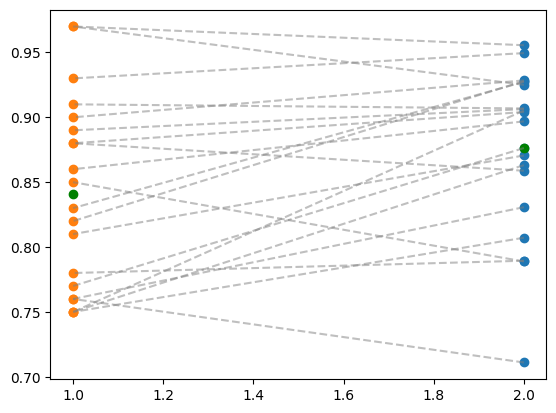

In [80]:
acc_handextracted = [.97,.75,.91,.75,.83,.97,.86,.81,.85,.88,.93,.82,.9,.75,.89,.77,.88,.76,.76,.78]
plt.scatter([2 for i in range(20)],tutte_acc)
plt.scatter([1 for i in range(20)],acc_handextracted)
for i in range(20):
    plt.plot([2, 1], [tutte_acc[i], acc_handextracted[i]], color="gray", alpha=0.5, linestyle="--")
plt.scatter([1], [np.mean(acc_handextracted)], color="green", label=f"Hand-extracted features (mean={np.mean(acc_handextracted):.2f})")
plt.scatter([2], [np.mean(tutte_acc)], color="green", label=f"DNN-extracted features (mean={np.mean(tutte_acc):.2f})")



In [67]:
np.mean(tutte_acc)

np.float64(0.8764639662882697)

In [72]:
np.mean([.97,.75,.91,.75,.83,.97,.86,.81,.85,.88,.93,.82,.9,.75,.89,.77,.88,.76,.76,.78])

np.float64(0.8410000000000002)

In [42]:
y_train_EEG.shape
Feat_train_regions_selected.shape


(124, 1120)

In [36]:
Features_training_1_regione.shape, Features_training_1_regione2.shape

((124, 80), (620, 16))

In [37]:
Feat_train_regions_selected.shape

(124, 1120)

In [38]:
80*14

1120

In [10]:
x_train_EEG.shape, x_val_EEG.shape, x_test_EEG.shape

((620, 256, 1), (80, 256, 1), (80, 256, 1))

In [22]:
160/5

32.0

In [23]:
len(train_idx)

124

## Form one subject to another - run in Training_DL_alternative.py 

In [ ]:
# nohup /home/silvia/Documents/GitHub/BCI_Project/.venv/bin/python /home/silvia/Documents/GitHub/BCI_Project/_Deep_Learning/Trainings_DL_alternative.py &> _Deep_Learning/LOGS/2nd_training/2026_02_16_10_30.txt
## Training From Donor Subject to Second Training Subject
# features extracted from the encoder of the model trained on the donor subject, 
# classification performed on Second-Training subject.
data_folder="Data/" #and libraries and funcitons
import sys
import numpy as np
import os
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from datetime import date
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.model_selection import StratifiedKFold, train_test_split
import tqdm
import re 

sys.path.append(os.path.abspath("Codes"))

sys.path.append(os.path.abspath("_Deep_Learning"))

from Utils import split_create_windows, scale_newax
from Utils import freq_filter, windowize,  RegionWiseStandardizer

from BCI_Library import read_subject, saveresults_pickle, compute_welch
from BCI_Library import  train_single_model,select_regions_Cohen_effect_size, build_compiled_mlp

import tensorflow.keras as keras

# print("\n\n",os.getcwd(),"\n\n")

def compute_power_spectra(data_2_MI, data_2_Rest, starttime=250, endtime=250):
    sfreq = 250
    miff = [8,12]
    maff = [12,30]

    WMI, WRe, FreqMI = compute_welch(data_2_MI, data_2_Rest, sfreq,
                                        kargs_welch={"fmin":miff[0], "fmax":maff[-1]},
                                        starttime=starttime, endtime=endtime,)

    return WMI, WRe


def selezione_cohen(WRe, WMI, train_idx, num_best_ROIs):
    training_index_Re = train_idx[np.where(train_idx<len(WRe))] 
    training_index_MI = train_idx[np.where(train_idx>=len(WRe))]-len(WRe)

    regions_selected, effect_size  = select_regions_Cohen_effect_size(wpsdMI=WMI[training_index_MI], 
                                                    wpsdRest=WRe[training_index_Re], 
                                                        important_regions=[], nbest_regions=num_best_ROIs)
    return regions_selected


######################################################################################################################################################

First_training_subjects = [_ for _ in range(20)]
Second_training_subjects = [_ for _ in range(20)]


Addestramento = "Encoder_timeseries_Decoder_spectra_log_simpleNormalization_EEG_MEG"

DataType = "EEG+MEG"
CNN_o_Autoencoder = "Autoencoder" # Autoencoder, # CNN, #SupervisedAutoencoder
region_specific = False
split_load_donor_network = 1

######################################################################################################################################################

pattern = re.compile(r"^\d{4}-\d{2}-\d{2}-\d{2}_\d{2}_\d{2}_" + re.escape(Addestramento) + r"$")

sfreq = 250
seed = 224
Features_name = CNN_o_Autoencoder + "_extracted"
Region_Selection= "Cohen's d effect size selection" # "-"
saveresults = True
filepath = "Results/BCI_Performances/DNN/BCI_Performances_DNN_cross_2_subjects_region_selection_from_3s.pkl"
PFR = True
random_seed=seed
num_best_ROIs = 8
verbose = False
Classifier_names, meths = ["SVC"],[SVC]  #["LDA", "SVC", "RandomForest"],[LDA, SVC, RandomForestClassifier] # ["MLP"], ["MLP"]
MLP_fit_kwargs={'epochs':20, 'batch_size':32}

######################################################################################################################################################

for donor_subject in First_training_subjects:
    print("\n\n","##"*25,"\n","subject ",donor_subject ,"\n","##"*25,"\n\n")

    model_path_1 = f"_Deep_Learning/Models_trained/Subject_"
    # model path 2 = f"{subject_index}/"
    # model path 2.5 = f"{DataType}/"
    model_path_3 = f"{CNN_o_Autoencoder}" + ("s/" if CNN_o_Autoencoder=="Autoencoder" else "/")

    mm = model_path_1 + f"{donor_subject}/" + f"{DataType}/" + model_path_3

    matching_addestramenti = [f for f in os.listdir(mm) if pattern.match(f)]
    
    if len(matching_addestramenti) != 1:
        raise Exception(f"Ho trovato {len(matching_addestramenti)} addestramenti corrispondenti a {Addestramento} per il soggetto {donor_subject}.", 
                        "Controlla bene se è quello che vuoi o se c'è un errore nei nomi delle cartelle.")
    model_path_4 = matching_addestramenti[0] + "/"

    lib_path = model_path_1 + f"{donor_subject}/" + f"{DataType}/" + model_path_3 + model_path_4
    sys.path.append(os.path.abspath(lib_path))

    try:
        del MultiTaskModel_PowerSpectra
        print("ho resettato MultiTaskModel")
    except:
        print("non ho resettato MultiTaskModel")

    try :
        from _Backup_Library import MultiTaskModel_PowerSpectra
    except:
        from Deep_Library_BCI import MultiTaskModel_PowerSpectra
        raise Exception("Non ho caricato dal backup, controlla bene se è quello che vuoi")

    use_GRU = True if "GRU" in model_path_4.replace("/","").split("_") else False

    if CNN_o_Autoencoder == "CNN":
        model = MultiTaskModel_PowerSpectra(input_shape=(256,2), output_shape=24, use_classifier=True, use_decoder=False, use_GRU=use_GRU, build_convolutional_decoder = True, EEG_concat_MEG = True)
    if CNN_o_Autoencoder == "Autoencoder":
        model = MultiTaskModel_PowerSpectra(input_shape=(256,2), output_shape=24, use_classifier=False, use_decoder=True, use_GRU=use_GRU, build_convolutional_decoder = True, EEG_concat_MEG = True)
    if CNN_o_Autoencoder == "SupervisedAutoencoder":
        try:
            model = MultiTaskModel_PowerSpectra(input_shape=(256,2), output_shape=24, use_classifier=True, use_decoder=True, use_GRU=use_GRU, build_convolutional_decoder = True, EEG_concat_MEG = True)
        except:
            model = MultiTaskModel_PowerSpectra(input_shape=(256,2), output_shape=24, use_classifier=True, use_decoder=True, build_convolutional_decoder = True, EEG_concat_MEG = True)

    model.build(input_shape=(256,2))

    model_path = model_path_1 + f"{donor_subject}/" + f"{DataType}/" + model_path_3 + model_path_4
    Comments = Addestramento+ f" Subject addestramento {donor_subject}"

    if region_specific:
        "DONE"
    else:
        model.load_weights(model_path+f"Split_{split_load_donor_network}/model.weights.h5")


    for secnd_train_subj in Second_training_subjects:
        # if secnd_train_subj == donor_subject:
        #     continue

        today = date.today()

        n_folds=5
        kf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=seed)
        today = date.today()

        start = 3           # seconds where to start to extract windows
        sampling_hz = 250;  start = start*sampling_hz
        input_shape = 256   # length of each window
        shift = 85          # points to shift for next window in data
        num_windows = 7     # how many windows to extract from each trial

        end = start + (num_windows-1)*shift + input_shape  # seconds where to end to extract windows (1500 == 6 seconds)


        rl = None
        for Classifier_name, meth in zip(Classifier_names,meths):
            
            Rows = pd.DataFrame({
                "ROIs": [],
                "NROIs":[],
                "DataType": [],
                "freqs_band": [],  
                "subject": [],
                "Classifier": [],
                "Accuracy": [],
                "Features": [],
                "Comments": [],
                "Region Selection": [],
                "Date": []
            })
            if rl is None: rl = Rows
        
            print("\n\n"+"#"*30+"\n",DataType,Classifier_name)
               
            file_input = filepath
            file_output = filepath

            data_2_Rest_EEG = read_subject(data_folder, "EEG", "Baseline",secnd_train_subj,verbose=verbose)
            data_2_MI_EEG = read_subject(data_folder, "EEG", "MI",secnd_train_subj,verbose=verbose)
            data_EEG = np.concatenate((data_2_Rest_EEG, data_2_MI_EEG), axis=0)
            WMI_EEG, WRe_EEG = compute_power_spectra(data_2_MI_EEG,data_2_Rest_EEG, starttime=750)
            data_EEG = freq_filter(data_EEG, sf=250, freqs=[4,45], type_filter="bandpass") # axis = -1 by default
            data_EEG = data_EEG[:,:,start:end]        #  data.shape = (192, rois_selected, 748)


            data_2_Rest_MEG = read_subject(data_folder, "MEG", "Baseline",secnd_train_subj,verbose=verbose)
            data_2_MI_MEG = read_subject(data_folder, "MEG", "MI",secnd_train_subj,verbose=verbose)
            data_MEG = np.concatenate((data_2_Rest_MEG, data_2_MI_MEG), axis=0)
            WMI_MEG, WRe_MEG = compute_power_spectra(data_2_MI_MEG,data_2_Rest_MEG, starttime=750)
            data_MEG = freq_filter(data_MEG, sf=250, freqs=[4,45], type_filter="bandpass") # axis = -1 by default
            data_MEG = data_MEG[:,:,start:end]        #  data.shape = (192, rois_selected, 748)



            # y shape: (n_trials,) with negative values for Rest and positive for MI
            y_EEG = np.concatenate([-np.ones((data_2_Rest_EEG.shape[0])), np.ones((data_2_MI_EEG.shape[0]))])
            y_MEG = np.concatenate([-np.ones((data_2_Rest_MEG.shape[0])), np.ones((data_2_MI_MEG.shape[0]))])

            assert np.array_equal(y_EEG, y_MEG), "Le etichette di EEG e MEG non corrispondono. Controlla i dati."
                
            fold_accuracies = []
            tutti_fold_selezioni_regioni = []
            for fold_idx, (train_idx, block_idx) in enumerate(kf.split(data_EEG, y_EEG)):
            ########################## DATA PREPROCESSING ##########################################
            # TODO create (num_windows,0)
                Feat_train_regions_selected = None  #np.empty((len(train_idx)*11,0))
                Feat_test_regions_selected = None # np.empty()
                
                # Scelta di regioni: scelgo tutte le regioni tra EEG e MEG
                regions_selected_EEG = selezione_cohen(WRe_EEG, WMI_EEG, train_idx, num_best_ROIs)
                regions_selected_MEG = selezione_cohen(WRe_MEG, WMI_MEG, train_idx, num_best_ROIs)
                regions_selected = list(set(regions_selected_EEG) | set(regions_selected_MEG))
                


                regions_selected.sort()
                print("\n Per il fold ", fold_idx, " Ho selezionato un numero di regioni pari a ", len(regions_selected), regions_selected)
                tutti_fold_selezioni_regioni.append(regions_selected)
                
                for region_index, regione in enumerate(regions_selected):
                    
                    split_num = fold_idx+1

                    x_train_MEG, y_train_MEG, x_val_MEG, y_val_MEG, x_test_MEG, y_test_MEG = (
                    split_create_windows(data_MEG, y_MEG, train_idx, block_idx, 1, win_len=input_shape, shift=shift,
                        random_seed=random_seed, regione=regione)
                        )

                    x_train_MEG, x_val_MEG, x_test_MEG = scale_newax (x_train_MEG, y_train_MEG, x_val_MEG, y_val_MEG, x_test_MEG, y_test_MEG, scaler=RegionWiseStandardizer())

                    x_train_EEG, y_train_EEG, x_val_EEG, y_val_EEG, x_test_EEG, y_test_EEG = (
                    split_create_windows(data_EEG, y_EEG, train_idx, block_idx, 1, win_len=input_shape, shift=shift,
                        random_seed=random_seed, regione=regione)
                        )
                
                    x_train_EEG, x_val_EEG, x_test_EEG = scale_newax (x_train_EEG, y_train_EEG, x_val_EEG, y_val_EEG, x_test_EEG, y_test_EEG, scaler=RegionWiseStandardizer())

                
                    # TODO unito EEG e MEG per train, val e test
                    x_train = np.concatenate((x_train_EEG, x_train_MEG), axis=-1)  # shape (n_windows, timepoints, 2)
                    x_test = np.concatenate((x_test_EEG, x_test_MEG), axis=-1)  # shape (n_windows, timepoints, 2)


                    Features_training_1_regione = model.encoder(x_train)
                    Features_test_1_regione = model.encoder(x_test)
                    # Features_training_1_regione  shape (n_windows,16)
                    
                    
                    ################################### Feature Extractions ##########################################
                    if Feat_train_regions_selected is None:
                        Feat_train_regions_selected = np.empty((Features_training_1_regione.shape[0],0))
                        Feat_test_regions_selected = np.empty((Features_test_1_regione.shape[0],0))

                    Feat_train_regions_selected = np.concatenate((Feat_train_regions_selected,tf.reshape(Features_training_1_regione, (Features_training_1_regione.shape[0], -1))),axis = 1) # asse di regione
                    Feat_test_regions_selected = np.concatenate((Feat_test_regions_selected,tf.reshape(Features_test_1_regione, (Features_test_1_regione.shape[0], -1))),axis = 1) # asse di regione


                Feat_All_regions_selected = np.concatenate((Feat_train_regions_selected,Feat_test_regions_selected))
                # Feat_.shape (Trials, selected_ROIs, features for Roi)
                labels_All = np.concatenate(((y_train_EEG > 0).astype(int),(y_test_EEG > 0).astype(int)))

                train_idx_model = [_ for _ in range(len(Feat_train_regions_selected))]
                val_idx_model = [_ + len(Feat_train_regions_selected) for _ in range(len(Feat_test_regions_selected))]


                if Classifier_name.lower()=="mlp":
                        meth = build_compiled_mlp(input_dim=Feat_All_regions_selected.shape[1])
                        
                acc, cm, model_classifier = train_single_model(Feat_All_regions_selected, labels_All,
                                                    train_idx_model, val_idx_model, method=meth, seed=224, fit_kwargs=MLP_fit_kwargs)

                fold_accuracies.append(acc)
                if verbose:
                    print(f"Fold {fold_idx+1} accuracy: {acc:.4f}, Confusion matrix:")
                    print(cm)

                #####################################################################################################################

            if verbose:
                print("\n==================================\n","Mean accuracy:", np.mean(fold_accuracies))
                print("Std accuracy:", np.std(fold_accuracies))

            new_row = {
                "ROIs": [regions_selected],
                "NROIs":[len(regions_selected)],
                "DataType": [DataType],
                "freqs_band": ["-"],  
                "subject": [secnd_train_subj],
                "Classifier": [Classifier_name], #SVC, #RandomForest, #LDA
                "Accuracy": [fold_accuracies],
                "Features": [Features_name],
                "Comments": [Comments],
                "Region Selection": [Region_Selection],
                "Date": [today],
                "Personalized_Freq_Range": ["-"],
            }
            Rows=pd.concat((Rows,pd.DataFrame(new_row)))
            rl = pd.concat((rl,Rows))
        

        if saveresults:
            saveresults_pickle(Rows, inputfile=file_input, outputfile=file_output, backup=True)